In [10]:
from  src.data_generator import DataGenerator
from src.models import LinearModel
import numpy as np
import matplotlib.pyplot as plt


In [7]:
''' Generating test_dataset also including true values. Kept the seed integer because test data doesnt change'''

error = 0.4 # This is standard deviation of normal distribution.
test_samplesize = 1000

test_data = DataGenerator(error, test_samplesize)
X_test, t_test, t_test_true  = test_data.Generate_Non_Linear_Data(42)

In [ ]:
''' Now creating training Datasets. We will calcualte Bias, Variance and Var(e) for each of the dataset. Code is slighlty complex, check the .xopp in PRML_MLE_ANALYSIS file to understand the math better.

For every degree code creates a new predictions matrix, because for every individual degree each training dataset is trained to that degree and we save predictions.
'''

bias_squared = []
variance = []
raw_mse = []

training_data = DataGenerator(error, 25)

num_of_training_datasets = 100

for d in range(1,16): # d is degree

    predictions_matrix = np.zeros(shape=(num_of_training_datasets, test_samplesize))

    for l in range(num_of_training_datasets):

        X_train, t_train, temp = training_data.Generate_Non_Linear_Data()

        model = LinearModel(d)
        model.fitNormalEquation(X_train, t_train)

        predictions = model.predict(X_test)

        predictions_matrix[l,:] = predictions[:,0]

    expected_predictions = (np.mean(predictions_matrix, axis=0)).reshape(-1,1)
    
    # Doing Bias Calculation
    bias_squared_per_point = (expected_predictions - t_test_true)**2
    total_bias_squared = np.mean(bias_squared_per_point) # This will return a single scaler value not a vector
    bias_squared.append(total_bias_squared)
    
    #Doing Variance Calculation
    variance_per_point = np.var(predictions_matrix, axis=0)
    total_variance = np.mean(variance_per_point) # This will also return a scalar value
    variance.append(total_variance)

    # Calculating Raw total MSE with noisy outputs
    t_test_noisy = t_test.flatten() # Using .flatten() to get to (N,) from column vector of (N,1) this will help code not to explode.

    raw_squared_errors = (predictions_matrix - t_test_noisy) ** 2 # Predictions matrix is (100, 1000) and subtatcitng a (1000,) t_test_noisy from it. It will take every column of predictions_matrix subtract t_test_noisy from it.

    noisy_mse = np.mean(raw_squared_errors) # This will take overall mean of full matrix. Giving us a single scalar ans
    raw_mse.append(noisy_mse)


bias_squared = np.array(bias_squared)
variance = np.array(variance)
theoretical_mse = bias_squared + variance + (error**2) # Theoritical mse or how raw mse is decomposed into this. Need to (error**2) because error is std_deviation 

raw_mse = np.array(raw_mse)



[0.44134828 0.44075019 0.31264042 0.31740292 0.3110821  0.31917072
 0.32097009 0.32497768 0.30635105 0.3115491  0.32090606 0.32070164
 1.98969622 0.33972632 0.3517871 ]
[0.44389388 0.44320071 0.30514587 0.3100527  0.30205055 0.31004592
 0.3106521  0.31493455 0.29618438 0.30151514 0.30993295 0.31003602
 1.97697963 0.32890903 0.33961722]


[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
[0.26537852 0.26388441 0.12855023 0.12895502 0.1161512  0.11776783
 0.11273003 0.11346827 0.0895385  0.08982544 0.0895111  0.08861352
 0.16685648 0.09523032 0.11004439]
[0.01596977 0.01686578 0.02409018 0.02844789 0.0349309  0.04140288
 0.04824006 0.05150941 0.05681255 0.06172365 0.07139496 0.07208811
 1.66283975 0.08449599 0.08174271]
[0.44134828 0.44075019 0.31264042 0.31740292 0.3110821  0.31917072
 0.32097009 0.32497768 0.30635105 0.3115491  0.32090606 0.32070164
 1.98969622 0.33972632 0.3517871 ]


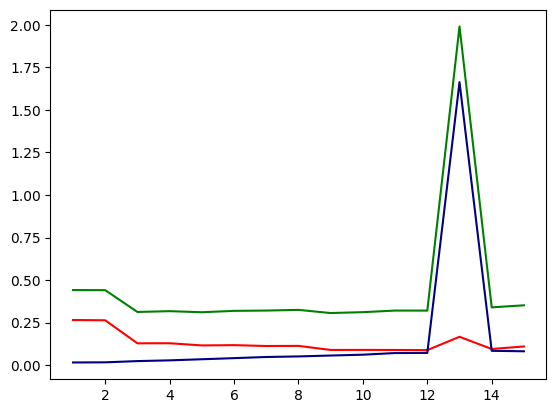

In [36]:
''' Plotting the Bias_Variance Tradeoff '''

degrees = np.arange(1,16)
print(degrees)
print(bias_squared)
print(variance)
print(theoretical_mse)

plt.plot(degrees, bias_squared, color='red')
plt.plot(degrees, variance, color='navy')
plt.plot(degrees, theoretical_mse, color='green')

